In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

from rebin_utils import downsample

#  H II region Data

In [3]:
line        = r'H$\alpha$'
lambda_rest = 6562.8
line_id     = 'H'
line_id2   = "H_I-6563"

In [4]:
# Data from observations
bins        = 0

region     = 'M 42'
name_reg   = 'Orion'
reg_id     = 'M42'
inst       = 'MUSE'
inst_id    = 'MUSE'
type_obj   = 'H II region'

pix        = 0.2   # Instrument resolution [arcsec/pix]
dist       = 410 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60) # value in parsecs of each arcsec
s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]

#Since we are working with matrix data binning can be applied
#name_file    =  inst_id + '-' + reg_id + '-' + line_id 
name_file    =  line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id + '-' + 'bin' + str(bins) + '-cont'
print(name_file)
print(name_id)

H_I-6563
MUSE-M42-H-bin0-cont


In [5]:
from pipeline_config import OBSERVATIONS_DIR

flux_path    = OBSERVATIONS_DIR / f'linesum-{name_file}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name_file}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)

In [6]:
sb = flux[0].data.astype(float)
vv = rad_vel[0].data.astype(float)
#ss    = np.array(_data['ss'])

# Continuum

In [7]:
# Loading obs
hdul_cont = fits.open('observations/continuum-H_I-6563-bin001.fits')
hdr_c = hdul_cont[0].header
print(hdul_cont.info())
print(hdr_c)
#sb_ha   = hdul['MOM0'].data.astype(float)
#vv_ha   = hdul['MOM1'].data.astype(float)
#mask    = hdul['MASK'].data.astype(bool)


Filename: observations/continuum-H_I-6563-bin001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SCALED        1 ImageHDU        26   (1792, 1536)   float64   
  2  WEIGHT        1 ImageHDU        26   (1792, 1536)   float64   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                 

In [8]:
scaled = hdul_cont[1].data.astype(float)
weight = hdul_cont[2].data.astype(float)

In [9]:
trim = (slice(0, 1476),slice(0, 1766))
scaled = scaled[trim]

In [10]:
m = ~np.isfinite(sb) | (sb < 0.0)
sb[m] = 0.0
sb   /= sb.max()


In [11]:
m = ~np.isfinite(scaled) | (scaled < 0.0)
scaled[m] = 0.0
scaled   /= scaled.max()


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\1117279643.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

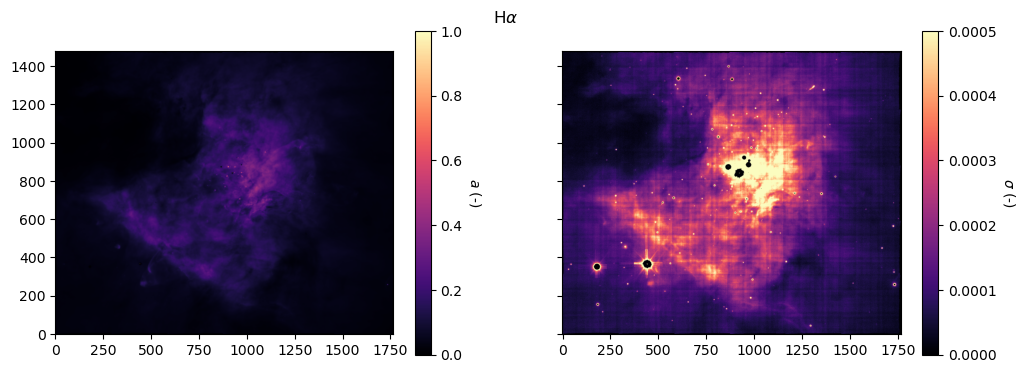

In [12]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( scaled,vmin = 0.0,vmax=0.0005, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\716080065.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\716080065.py:9: RuntimeWarning: divide by zero encountered in divide
  im = ax.imshow( sb/scaled,vmin=0, vmax=1000, **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\716080065.py:9: RuntimeWarning: invalid value encountered in divide
  im = ax.imshow( sb/scaled,vmin=0, vmax=1000, **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\716080065.py:12: RuntimeWarning: divide by zero encountered in divide
  im = axx.imshow(scaled/sb,vmin=0, vmax=0.002, **imshow_kwds2)
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\716080065.py:12: RuntimeWarning: invalid value encountered in divide
  im = axx.imshow(scaled/sb,vmin=0, vmax=0.002, **imshow_kwds2)

Text(0.5, 0.8, 'H$\\alpha$')

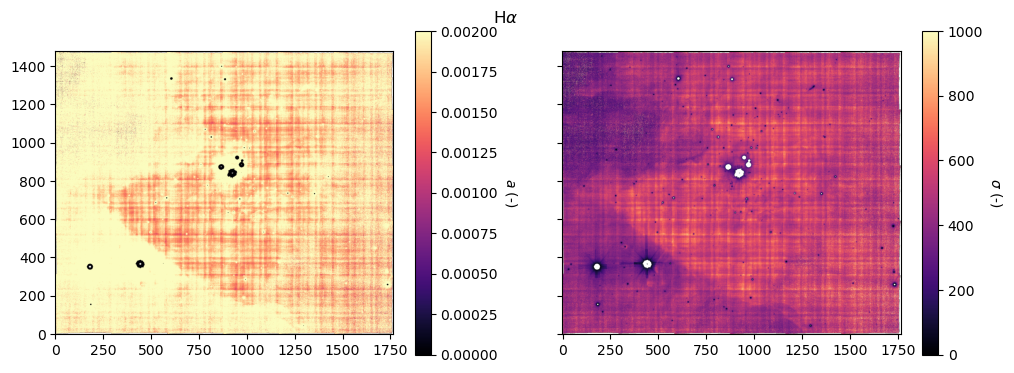

In [13]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( sb/scaled,vmin=0, vmax=1000, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(scaled/sb,vmin=0, vmax=0.002, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [14]:
scaled_sb = scaled/sb

C:\Users\javas\AppData\Local\Temp\ipykernel_14580\3266746249.py:1: RuntimeWarning: divide by zero encountered in divide
  scaled_sb = scaled/sb
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\3266746249.py:1: RuntimeWarning: invalid value encountered in divide
  scaled_sb = scaled/sb


In [15]:
m = ~np.isfinite(scaled_sb) | (scaled_sb < 0.0)
scaled_sb[m] = 0.0
scaled_sb   /= scaled_sb.max()

In [16]:
sb_scaled = sb/scaled

C:\Users\javas\AppData\Local\Temp\ipykernel_14580\2307350520.py:1: RuntimeWarning: divide by zero encountered in divide
  sb_scaled = sb/scaled
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\2307350520.py:1: RuntimeWarning: invalid value encountered in divide
  sb_scaled = sb/scaled


In [17]:
m = ~np.isfinite(sb_scaled) | (sb_scaled < 0.0)
sb_scaled[m] = 0.0
sb_scaled   /= sb_scaled.max()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\2993969812.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

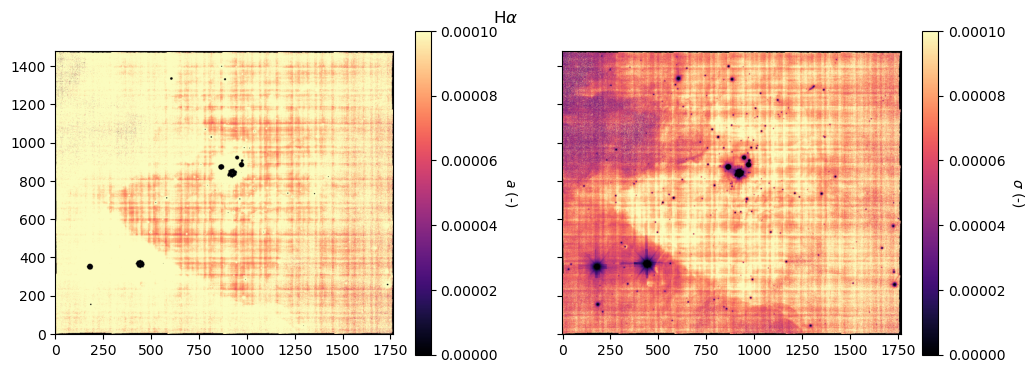

In [18]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( sb_scaled,vmin=0, vmax=0.0001, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(scaled_sb,vmin=0, vmax=0.0001, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [19]:
scaled_sb

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.00061165, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00068404, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [20]:
mask_bool = scaled_sb.astype(bool)

In [21]:
mask_bool

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [22]:
# Loading obs
hdul = fits.open("fits_ready/MUSE-M42-H-bin0.fits")
hdr = hdul[0].header
print(hdul.info())
print(hdr)
mask_vv = hdul['MASK'].data.astype(bool)


Filename: fits_ready/MUSE-M42-H-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (1766, 1476)   float64   
  2  MOM1          1 ImageHDU         8   (1766, 1476)   float64   
  3  MASK          1 ImageHDU         8   (1766, 1476)   uint8   
  4  TABLE         1 BinTableHDU     23   67R x 7C   [D, D, D, D, K, D, D]   
  5  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'H_I-6563'           / Fits file name                                 NAME_ID = 'MUSE-M42-H-bin0'    / pipeline identifier                            REG     =

In [23]:
mu = vv.mean()
sb_m = np.where(mask_bool & mask_vv, sb, np.nan)
vv_m = np.where(mask_bool & mask_vv, vv, mu)    

In [24]:
mask_global = mask_bool & mask_vv

In [25]:
hdu_mk = fits.ImageHDU(data=mask_global.astype(np.uint8) ,  name='MASK')

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_14580\3418306662.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

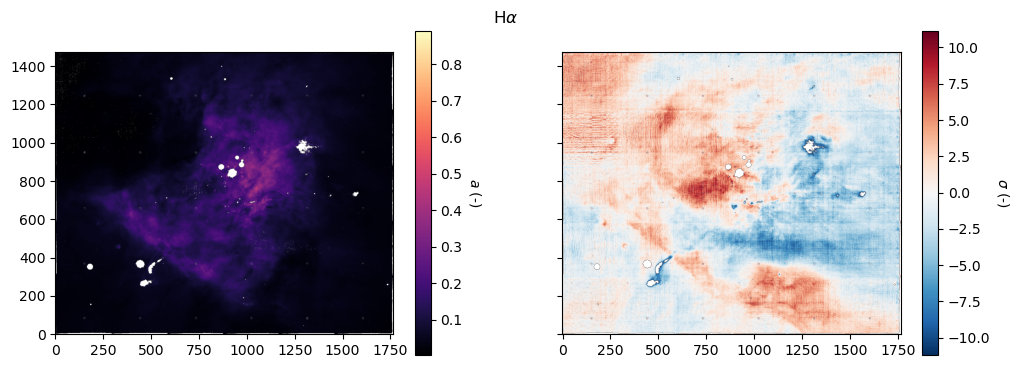

In [26]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m-np.nanmean(vv_m), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Sigma

In [27]:
# Loading obs
hdul_sigma = fits.open("observations/sigma-H_I-6563-fuzz000.fits")
hdr = hdul_sigma[0].header
print(hdul.info())
print(hdr)

Filename: fits_ready/MUSE-M42-H-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (1766, 1476)   float64   
  2  MOM1          1 ImageHDU         8   (1766, 1476)   float64   
  3  MASK          1 ImageHDU         8   (1766, 1476)   uint8   
  4  TABLE         1 BinTableHDU     23   67R x 7C   [D, D, D, D, K, D, D]   
  5  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1766                                                  NAXIS2  =                 1476                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =

In [28]:
sigma = hdul_sigma[0].data.astype(float)


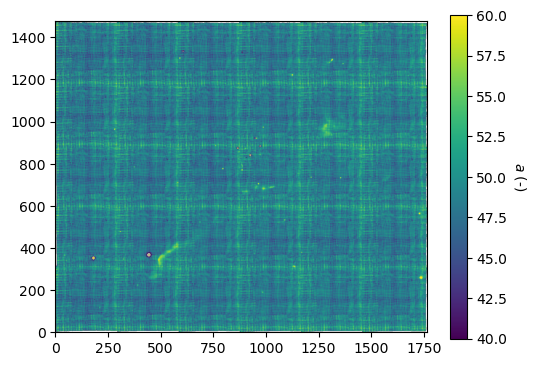

In [29]:
fig, axx = plt.subplots(figsize=(6, 6))

imshow_kwds2 = dict(origin="lower", cmap="viridis")

im = axx.imshow(sigma,vmin=40, vmax=60, **imshow_kwds2)
cbar = fig.colorbar(im, ax=axx, shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

#fig.suptitle(line, y=0.95)

# plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')
plt.show()

In [30]:
# Loading obs
hdul_sigma = fits.open("observations/sigma-H_I-6563-fuzz001.fits")
hdr = hdul_sigma[0].header
print(hdul.info())
print(hdr)

Filename: fits_ready/MUSE-M42-H-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (1766, 1476)   float64   
  2  MOM1          1 ImageHDU         8   (1766, 1476)   float64   
  3  MASK          1 ImageHDU         8   (1766, 1476)   uint8   
  4  TABLE         1 BinTableHDU     23   67R x 7C   [D, D, D, D, K, D, D]   
  5  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1766                                                  NAXIS2  =                 1476                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =

In [31]:
sigma = hdul_sigma[0].data.astype(float)

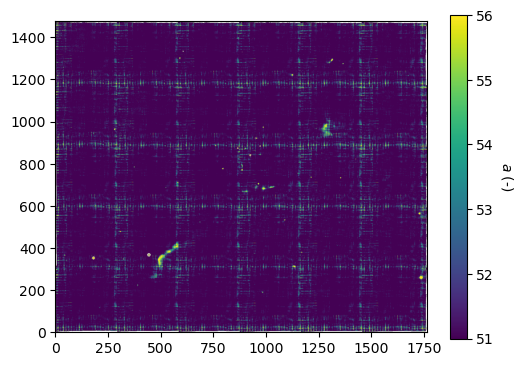

In [32]:
fig, axx = plt.subplots(figsize=(6, 6))

imshow_kwds2 = dict(origin="lower", cmap="viridis")

im = axx.imshow(sigma,vmin=51, vmax=56, **imshow_kwds2)
cbar = fig.colorbar(im, ax=axx, shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

#fig.suptitle(line, y=0.95)

# plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')
plt.show()

In [33]:
xxxx

NameError: name 'xxxx' is not defined

In [ ]:
N = np.sqrt(vv_m.shape[0] * vv_m.shape[1]) * pix * pc
N

In [ ]:
sig = np.nanstd(vv_m)
sig

# Downsample

# Export

In [ ]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc* (2**bins), "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [ ]:
hdu_m0 = fits.ImageHDU(data=sb_m,  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m,  name='MOM1')
#hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
hdu_mk = fits.ImageHDU(data=good.astype(np.uint8) ,  name='MASK')

In [ ]:
#hdul = fits.HDUList([primary, hdu_m0, hdu_m1, hdu_mk])
#hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()
    
hdr = hdul[0].header
print(hdr)
